Часть А (загрузка и подготовка изображения)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
import os
# переводим изображение в чб формат с помощью .convert('L')
img = Image.open('dog.jpg').convert('L')

img_array = np.array(img) # преобразование картинки в массив, матрица h*w
h, w = img_array.shape # h - height, w - weight
original_shape = img_array.shape #сохраняем исходную форму матрицы для автопроверки
original_flat = img_array.flatten() # превращаем матрцу в вектор длины h*w

**Выводы:** Изображение загружено, сконвертировано в чб. Теперь это матрица h*w, где каждое значение - число от 0 до 255.

Часть Б (Применение SVD и восстановление)

In [14]:
# разложение матрицы по формуле SVD (full_matrices=False экономит память)
U, s, Vt = np.linalg.svd(img_array, full_matrices=False)
# Cжатие (аппроксимация) для разных рангов (последний - максимально возможный)
list_of_ranks = [1, 5, 10, 30, 100, min(h, w)]
approximations = []

for r in list_of_ranks:
    # U - h*r, s - r, Vt - r*w, получим формулу из подсказки (U[:,:r] * s[:r]) @ Vt[:r,:]  = h*w
    approx = (U[:, :r] * s[:r]) @ Vt[:r, :] # формула восстановления
    approximations.append(approx)

**Выводы:** Матрица изображения разложена на три A=U*Σ*V^T. Изображения были восстановлены для разных рангов ([1, 5, 10, 30, 100, min(h, w)]). Чем больше
, тем больше деталей сохраняется.
​


Часть В + Г

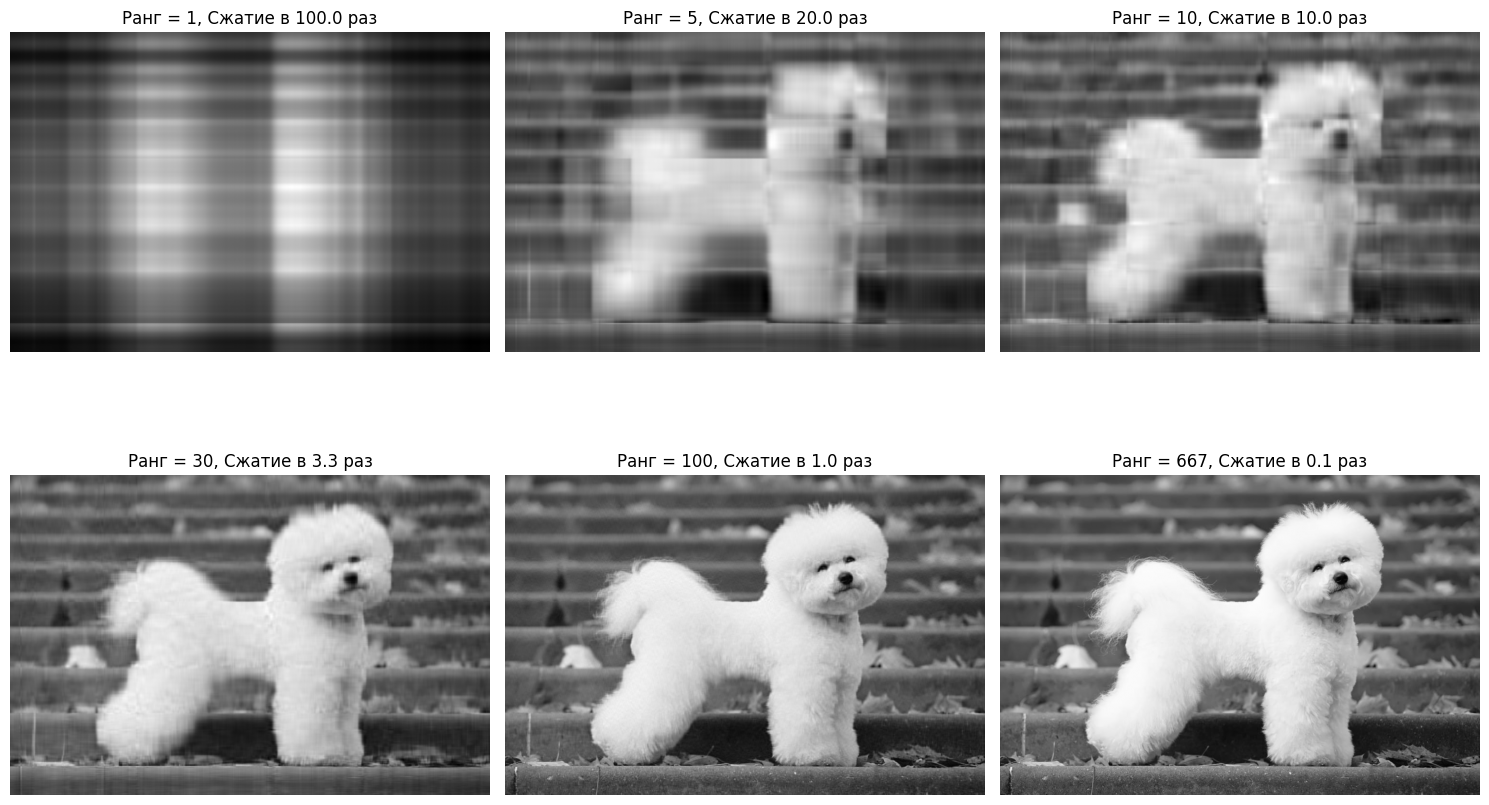

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10)) # параметры для большого графика
axes = axes.flatten()
original_size_bytes = h * w * 1 # исходный размер в байтах - 1Б * пиксель для ЧБ

for i, r in enumerate(list_of_ranks):
    # размер сжатой картинки: r * (h + 1 + w) чисел, формула см часть Г. float32 = 4Б
    compressed_size_bytes = r * (h + 1 + w) * 4
    compression_ratio = original_size_bytes / compressed_size_bytes

    axes[i].imshow(approximations[i], cmap='gray')
    axes[i].set_title(f"Ранг = {r}, Сжатие в {compression_ratio:.1f} раз")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Выводы:** Создан один график размером 2x3, где на каждом подграфике отображается восстановленное изображение с обределённым рангом. Для каждого подграфика есть подпись. Последнее изображение - оригинал. Можно заметить, что при малых рангах видна только общая структура и контраст. Начиная с ранга 30, изображение сложно отличить от оригинала, но сжатие значительно.

In [6]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка диапазона значений
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255)
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка монотонности MSE
mse_list = []
for i in range(len(approximations)):
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


**ответы на вопросы**
1) При каком ранге визуальное качество перестает отличаться от оригинала?
Начиная с 30 и менее ранга визуальное качество перестаёт отличаться от оригинала.
2) Для какого ранга достигается сжатие в 10 раз?
Для 10 ранга достигается сжатие в 10 раз для данного изображения.
3) Почему для темных/светлых участков ошибка разная?
На светлых (ближе к белому) участках ошибка максимальна, тк значение пикселей близко к 255. На тёмных участках иначе, тк значение близко к 0, поэтому ошибка при r минимальна.
SVD отбрасывает значения на учатсках с мелкими деталями, текстурами и шумом, которые требуют высоких рангов, поэтому на них ошибка при низких r максимальна.